<a href="https://colab.research.google.com/github/dhrubo404/IPA/blob/main/IPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The goal:
1. A simple queue simulator
2. Plot queue trajectory
3. Add IPA estimators
4. Plot convergence of IPA estimates to true derivatives

In [108]:
import numpy as np
import matplotlib.pyplot as plt

In [109]:
# User inputs
lambda_rate = float(input("Enter arrival rate (lambda): "))
mu_rate = float(input("Enter service rate (mu): "))
N = int(input("Enter number of customers (simulation length): "))
seed = int(input("Enter random seed: "))

if lambda_rate >= mu_rate:
    raise ValueError("System unstable: need lambda < mu.")

Enter arrival rate (lambda): 0.8
Enter service rate (mu): 1.2
Enter number of customers (simulation length): 10000
Enter random seed: 30


## Queue Model

Let
* $A_i$ - interarrival time between customer $i_1$ and customer $i$
* $S_i$ - service time of customer $i$
* $W_i$ - waiting time in queue of customer $i$
* $T_i = W_i +S_i$ - system time of customer $i$

For a FCFS single-server queue, Lindley's recusrion is
$$W_i = \max\{0,; W_{i-1} + S_{i-1} - A_i\}, \qquad i\ge 2$$
with $W_1=0$

Arrival and service times are generated as
$$A_i \sim \text{Exp}(\lambda) ,\qquad S_i\sim \text{Exp}(\mu)$$


In [110]:
def simulate_mm1(lambda_rate, mu_rate, N, seed):

    if lambda_rate <= 0 or mu_rate <= 0:
        raise ValueError("lambda_rate and mu_rate must be positive.")
    if lambda_rate >= mu_rate:
        raise ValueError("Need lambda_rate < mu_rate for a stable M/M/1 queue.")

    rng = np.random.default_rng(seed)

    # Generate primitive random variables
    interarrivals = rng.exponential(scale=1/lambda_rate, size=N)
    services = rng.exponential(scale=1/mu_rate, size=N)

    # Arrival times
    arrivals = np.cumsum(interarrivals)

    # State arrays
    wait_q = np.zeros(N)
    start_service = np.zeros(N)
    departures = np.zeros(N)
    system_times = np.zeros(N)

    # First customer
    start_service[0] = arrivals[0]
    departures[0] = start_service[0] + services[0]
    system_times[0] = services[0]

    # Remaining customers
    for i in range(1, N):
        wait_q[i] = max(0.0, departures[i-1] - arrivals[i]) ## Lindley's
        start_service[i] = arrivals[i] + wait_q[i]
        departures[i] = start_service[i] + services[i]
        system_times[i] = wait_q[i] + services[i]

    return {
        "interarrivals": interarrivals,
        "services": services,
        "arrivals": arrivals,
        "wait_q": wait_q,
        "start_service": start_service,
        "departures": departures,
        "system_times": system_times
    }

## Simulation and basic plots


In [111]:
sim = simulate_mm1(lambda_rate,mu_rate,N,seed)
arrivals = sim["arrivals"]
departures = sim["departures"]
wait_q = sim["wait_q"]
system_times = sim["system_times"]
services = sim["services"]

print(f"Sample Average system time={np.mean(system_times):.6f}")
print(f"Theoretical mean system time ={1/(mu_rate-lambda_rate):.6f}")

Sample Average system time=2.450563
Theoretical mean system time =2.500000


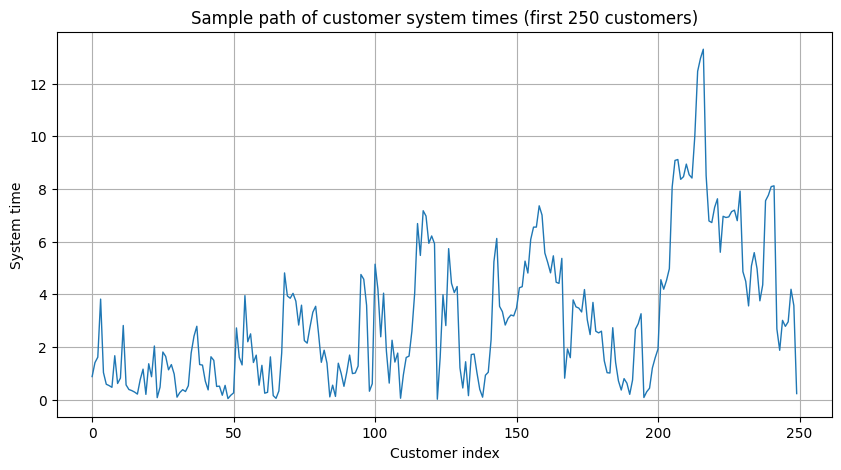

In [112]:
plt.figure(figsize=(10,5))
plt.plot(system_times[:250], linewidth=1)
plt.xlabel("Customer index")
plt.ylabel("System time")
plt.title(f"Sample path of customer system times (first 250 customers)")
plt.grid(True)
plt.show()

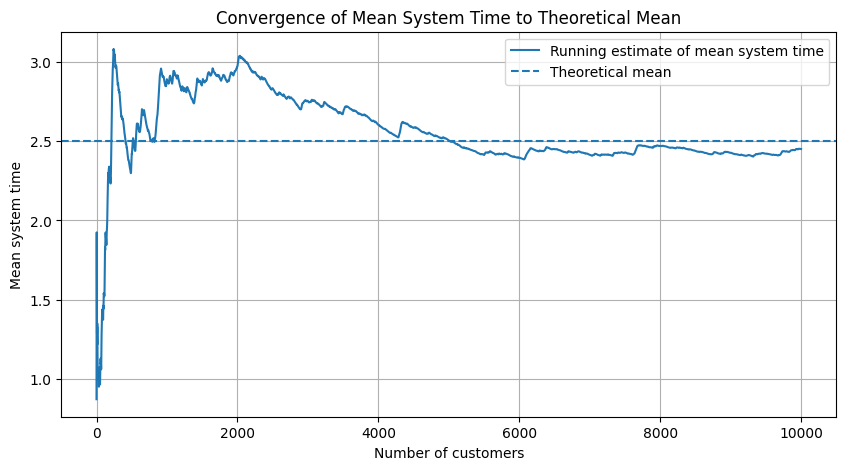

In [113]:
running_mean_T = np.cumsum(system_times) / np.arange(1, N+1)

plt.figure(figsize=(10,5))
plt.plot(running_mean_T, label="Running estimate of mean system time")
plt.axhline(1/(mu_rate-lambda_rate), linestyle="--", label="Theoretical mean")
plt.xlabel("Number of customers")
plt.ylabel("Mean system time")
plt.title("Convergence of Mean System Time to Theoretical Mean")
plt.grid(True)
plt.legend()
plt.show()

## IPA estimator with respect to the arrival rate $\mu$

$$W_i = \max\{0,\;W_{i-1}+S_{i-1}-A_i\}$$

So on sample paths where the inside of the max is positive,

$$D_i^{(\mu)}=D_{i-1}^{(μ)}+\frac{dS_{i-1}}{dμ}$$

If system becomes empty before customer $i$, the pertubation resets to zero:
$$D_i^{(\mu)}=\begin{cases}D_{i-1}^{(\mu)} - \dfrac{S_{i-1}}{\mu}, & \text{if } W_{i-1}+S_{i-1}-A_i > 0,\\[1em]
0, & \text{otherwise.}\end{cases}$$

Since
$$T_i = W_i+S_i,$$

we get

$$\frac{dT_i}{d\mu}=D_i^{(\mu)}-\frac{S_i}{\mu}$$

Therefore IPA estimator is
$$\boxed{
\left[\frac{dJ}{d\mu}\right]_{\text{IPA}}
=
\frac{1}{N}\sum_{i=1}^N \left(D_i^{(\mu)} - \frac{S_i}{\mu}\right)
}$$


## IPA estimator with respect to the arrival rate $\lambda$

Write interarrival times as
$$
A_i = \frac{-\ln V_i}{\lambda}.
$$
Then
$$
\frac{dA_i}{d\lambda} = -\frac{A_i}{\lambda}.
$$

Let
$$
D_i^{(\lambda)} = \frac{dW_i}{d\lambda}.
$$

Again from Lindley's recursion, when the queue remains busy,
$$
D_i^{(\lambda)}
= D_{i-1}^{(\lambda)} - \frac{dA_i}{d\lambda}
= D_{i-1}^{(\lambda)} + \frac{A_i}{\lambda}.
$$
If the system empties before customer $i$, the perturbation is reset:
$$
D_i^{(\lambda)} =
\begin{cases}
D_{i-1}^{(\lambda)} + \dfrac{A_i}{\lambda}, & \text{if } W_{i-1}+S_{i-1}-A_i > 0,\\[1em]
0, & \text{otherwise.}
\end{cases}
$$

Since service times do not depend on $\lambda$,

$$\frac{dT_i}{d\lambda} = D_i^{(\lambda)}.$$


Thus
$$
\boxed{
\left[\frac{dJ}{d\lambda}\right]_{\text{IPA}}
=
\frac{1}{N}\sum_{i=1}^N D_i^{(\lambda)}
}
$$

### Interpretation

A perturbation in an interarrival time affects future waiting times only if it occurs during a busy period. Once the system empties, that perturbation no longer propagates.

In [114]:
def ipa_estimators_mm1(lambda_rate, mu_rate, N, seed):



    rng = np.random.default_rng(seed)

    # Use inverse transform so dependence on lambda and mu is explicit
    U_arr = rng.uniform(size=N)
    U_srv = rng.uniform(size=N)

    interarrivals = -np.log(U_arr) / lambda_rate
    services = -np.log(U_srv) / mu_rate

    arrivals = np.cumsum(interarrivals)

    wait_q = np.zeros(N)
    departures = np.zeros(N)
    system_times = np.zeros(N)

    # IPA derivative states
    dW_dmu = np.zeros(N)
    dW_dlambda = np.zeros(N)
    dT_dmu = np.zeros(N)
    dT_dlambda = np.zeros(N)

    # first customer
    departures[0] = arrivals[0] + services[0]
    system_times[0] = services[0]

    # derivatives for first customer
    dT_dmu[0] = -services[0] / mu_rate
    dT_dlambda[0] = 0.0

    for i in range(1, N):
        x = wait_q[i-1] + services[i-1] - interarrivals[i]

        if x > 0:
            wait_q[i] = x
            dW_dmu[i] = dW_dmu[i-1] - services[i-1] / mu_rate
            dW_dlambda[i] = dW_dlambda[i-1] + interarrivals[i] / lambda_rate
        else:
            wait_q[i] = 0.0
            dW_dmu[i] = 0.0
            dW_dlambda[i] = 0.0

        departures[i] = arrivals[i] + wait_q[i] + services[i]
        system_times[i] = wait_q[i] + services[i]

        dT_dmu[i] = dW_dmu[i] - services[i] / mu_rate
        dT_dlambda[i] = dW_dlambda[i]

    # running estimators
    running_J = np.cumsum(system_times) / np.arange(1, N+1)
    running_dJ_dmu = np.cumsum(dT_dmu) / np.arange(1, N+1)
    running_dJ_dlambda = np.cumsum(dT_dlambda) / np.arange(1, N+1)

    return {
        "interarrivals": interarrivals,
        "services": services,
        "arrivals": arrivals,
        "wait_q": wait_q,
        "departures": departures,
        "system_times": system_times,
        "dT_dmu": dT_dmu,
        "dT_dlambda": dT_dlambda,
        "running_J": running_J,
        "running_dJ_dmu": running_dJ_dmu,
        "running_dJ_dlambda": running_dJ_dlambda
    }

In [115]:

out = ipa_estimators_mm1(lambda_rate=lambda_rate, mu_rate=mu_rate, N=N, seed=seed)

theory_J = 1 / (mu_rate - lambda_rate)
theory_dJ_dmu = -1 / (mu_rate - lambda_rate)**2
theory_dJ_dlambda = 1 / (mu_rate - lambda_rate)**2

print("Final simulation estimates")
print("-" * 40)
print(f"Mean system time estimate   = {out['running_J'][-1]:.6f}")
print(f"Theoretical mean system time= {theory_J:.6f}")
print()
print(f"IPA estimate dJ/dmu         = {out['running_dJ_dmu'][-1]:.6f}")
print(f"Theoretical dJ/dmu          = {theory_dJ_dmu:.6f}")
print()
print(f"IPA estimate dJ/dlambda     = {out['running_dJ_dlambda'][-1]:.6f}")
print(f"Theoretical dJ/dlambda      = {theory_dJ_dlambda:.6f}")

Final simulation estimates
----------------------------------------
Mean system time estimate   = 2.682480
Theoretical mean system time= 2.500000

IPA estimate dJ/dmu         = -6.689339
Theoretical dJ/dmu          = -6.250000

IPA estimate dJ/dlambda     = 6.680909
Theoretical dJ/dlambda      = 6.250000


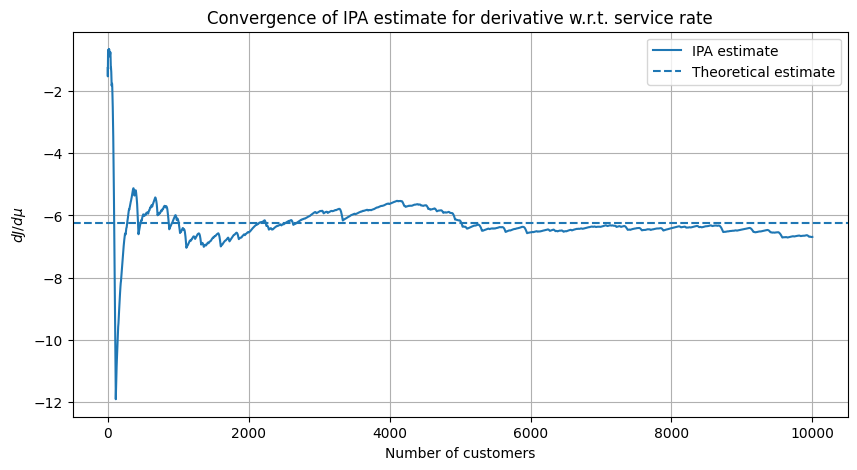

In [116]:
plt.figure(figsize=(10,5))
plt.plot(out["running_dJ_dmu"], label="IPA estimate")
plt.axhline(theory_dJ_dmu, linestyle="--", label="Theoretical estimate")
plt.xlabel("Number of customers")
plt.ylabel(r"$dJ/d\mu$")
plt.title("Convergence of IPA estimate for derivative w.r.t. service rate")
plt.grid(True)
plt.legend()
plt.show()

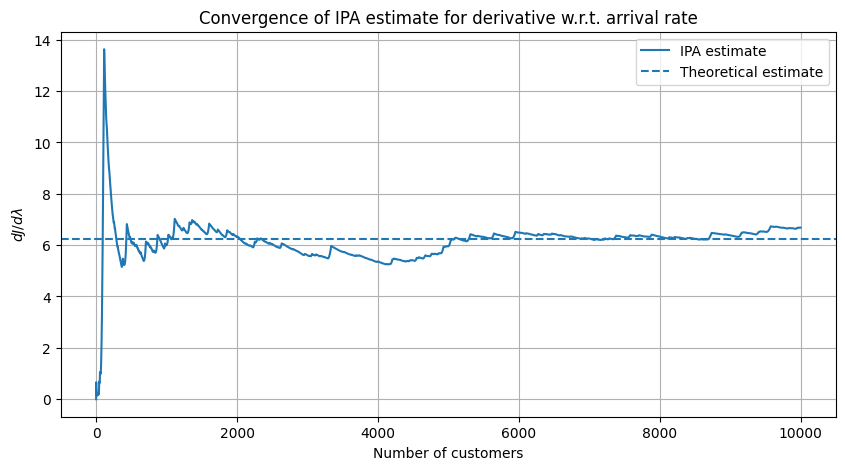

In [117]:
plt.figure(figsize=(10,5))
plt.plot(out["running_dJ_dlambda"], label="IPA estimate")
plt.axhline(theory_dJ_dlambda, linestyle="--", label="Theoretical estimate")
plt.xlabel("Number of customers")
plt.ylabel(r"$dJ/d\lambda$")
plt.title("Convergence of IPA estimate for derivative w.r.t. arrival rate")
plt.grid(True)
plt.legend()
plt.show()